In [1]:
from datasets import load_dataset
import pandas as pd
import kagglehub

/home/velocitatem/.jupyter_venvs/SL_final_project/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("aharley/rvl_cdip", trust_remote_code=True)

In [3]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 320000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 40000
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 40000
    })
})

In [4]:
train = dataset['train'].shuffle(seed=42).select(range(1000))
train = pd.DataFrame(train)

In [5]:
train.head()

,image,label
0,<PIL.Image.Image image mode=L size=731x1000 at...,12
1,<PIL.Image.Image image mode=L size=754x1000 at...,11
2,<PIL.Image.Image image mode=L size=754x1000 at...,2
3,<PIL.Image.Image image mode=L size=762x1000 at...,11
4,<PIL.Image.Image image mode=L size=784x1000 at...,1


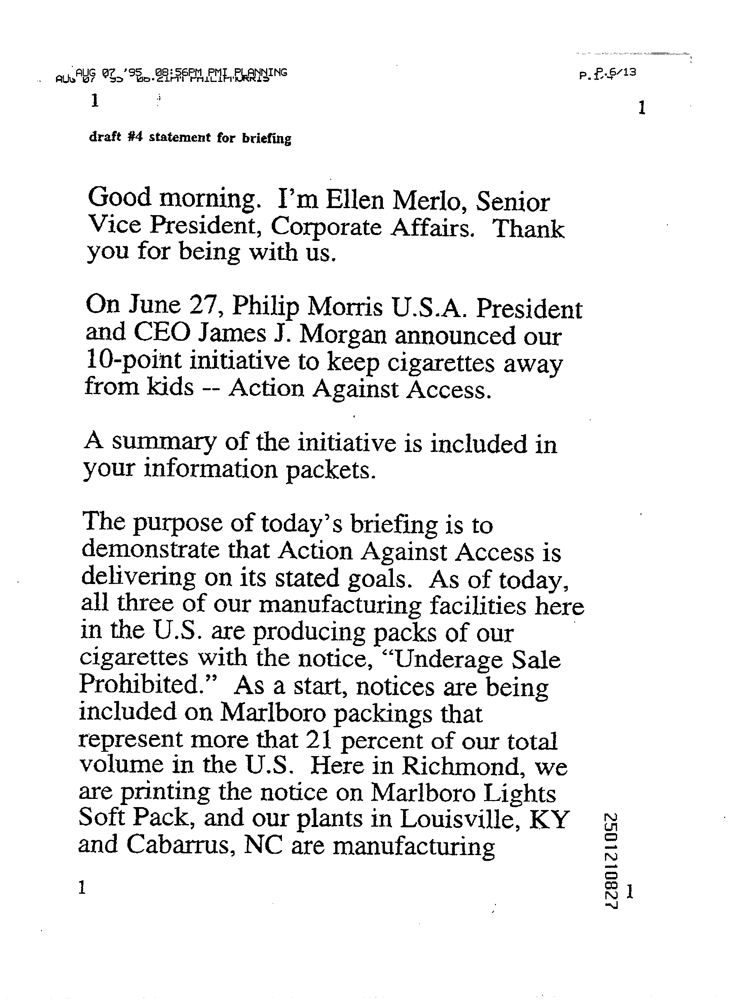

In [6]:
train.iloc[0]['image']

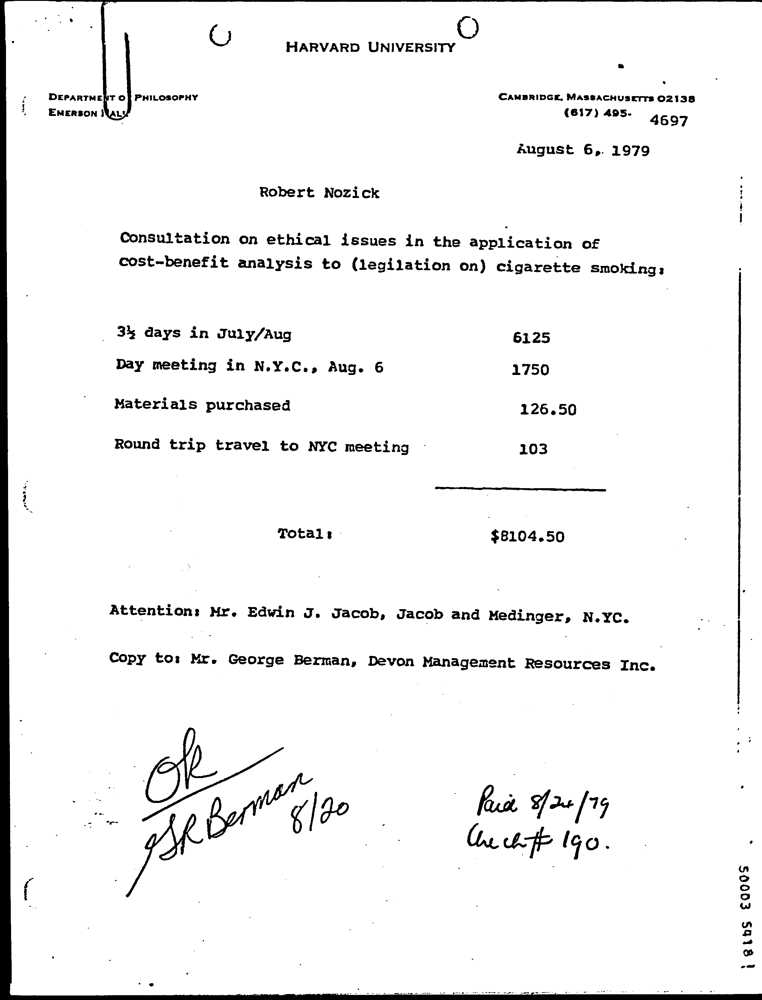

In [7]:
train[train['label'] == 11].iloc[10]['image']

In [8]:
path = kagglehub.dataset_download("ayoubcherguelaine/company-documents-dataset")
!ls {path}

CompanyDocuments  company-document-text.csv


Total images analyzed: 1829
Width: min=625, max=1654, mean=1168.64, median=787.0
Height: min=1000, max=2339, mean=1607.64, median=1000.0


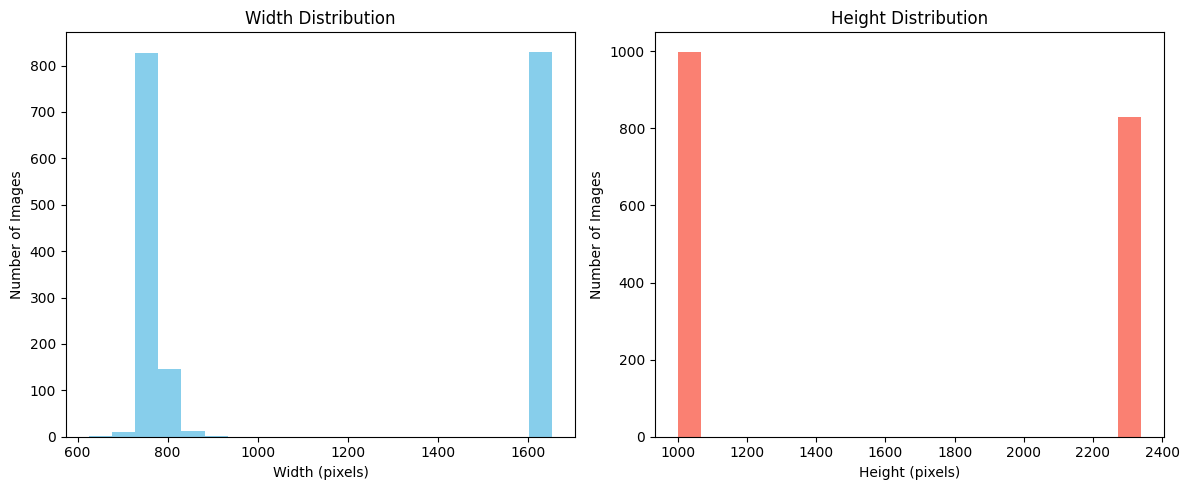

Suggested CNN input dimension: 768x992


In [1]:
import zipfile
from io import BytesIO
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
zip_file_path = '03-17-2025-17-33-35_files_list.zip'

widths, heights = [], []

with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    image_files = [f for f in zip_ref.namelist() if f.lower().endswith(('png', 'jpg', 'jpeg'))]

    for img_name in image_files:
        with zip_ref.open(img_name) as img_file:
            try:
                img = Image.open(BytesIO(img_file.read()))
                widths.append(img.width)
                heights.append(img.height)
            except Exception as e:
                print(f"Error loading {img_name}: {e}")

# Convert to numpy arrays for analysis
widths, heights = np.array(widths), np.array(heights)

# Print statistics
print(f"Total images analyzed: {len(widths)}")
print(f"Width: min={widths.min()}, max={widths.max()}, mean={widths.mean():.2f}, median={np.median(widths)}")
print(f"Height: min={heights.min()}, max={heights.max()}, mean={heights.mean():.2f}, median={np.median(heights)}")

# Plot distribution for visual insight
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(widths, bins=20, color='skyblue')
plt.title('Width Distribution')
plt.xlabel('Width (pixels)')
plt.ylabel('Number of Images')

plt.subplot(1, 2, 2)
plt.hist(heights, bins=20, color='salmon')
plt.title('Height Distribution')
plt.xlabel('Height (pixels)')
plt.ylabel('Number of Images')

plt.tight_layout()
plt.show()

# Suggest CNN input size (close to median or rounded mean)
suggested_width = int(np.median(widths) // 32 * 32)
suggested_height = int(np.median(heights) // 32 * 32)

print(f"Suggested CNN input dimension: {suggested_width}x{suggested_height}")


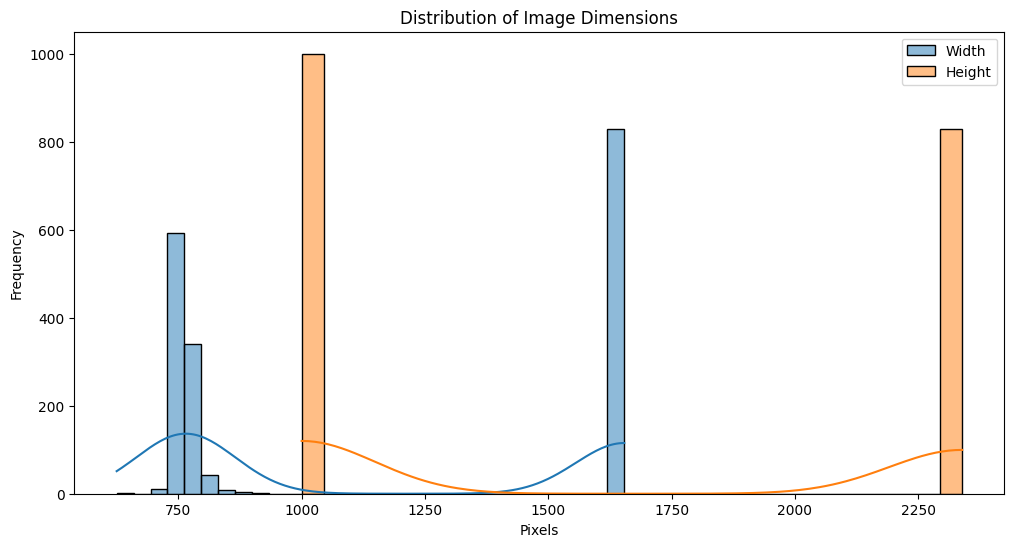

In [17]:
image_sizes = [img.size for img in jf['image']]
widths, heights = zip(*image_sizes)

plt.figure(figsize=(12, 6))
sns.histplot(widths, bins=30, kde=True, label="Width")
sns.histplot(heights, bins=30, kde=True, label="Height")
plt.legend()
plt.xlabel("Pixels")
plt.ylabel("Frequency")
plt.title("Distribution of Image Dimensions")
plt.show()

In [ ]:
image_sizes

In [2]:
import numpy as np
np.mean(image_sizes)

NameError: name 'image_sizes' is not defined

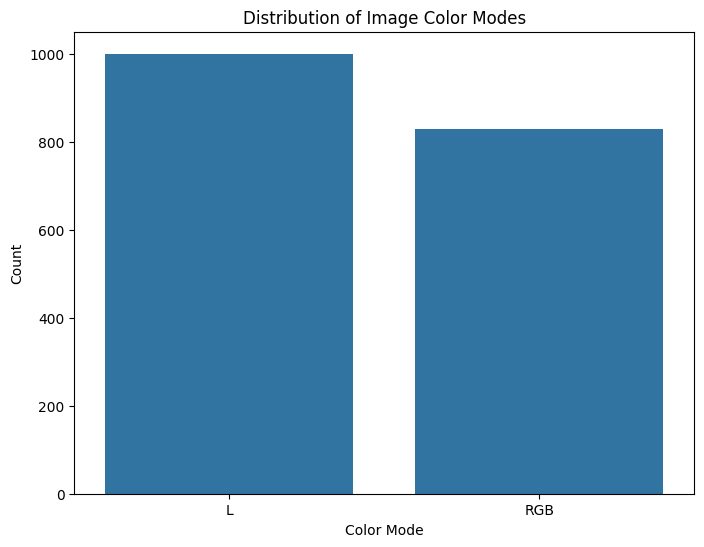

In [19]:
from collections import Counter
color_modes = [img.mode for img in jf['image']]
color_counts = Counter(color_modes)

plt.figure(figsize=(8, 6))
sns.barplot(x=list(color_counts.keys()), y=list(color_counts.values()))
plt.xlabel("Color Mode")
plt.ylabel("Count")
plt.title("Distribution of Image Color Modes")
plt.show()

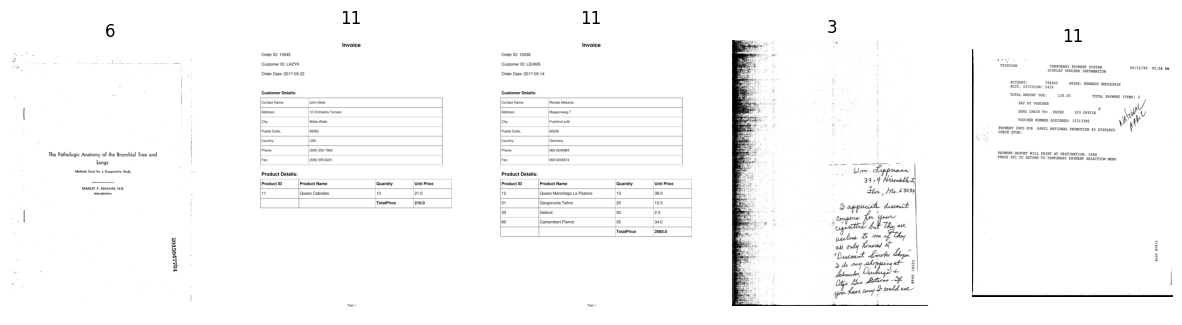

In [25]:
sample_images = jf.sample(5)

fig, axes = plt.subplots(1, 5, figsize=(15, 5))
for ax, (img, label) in zip(axes, zip(sample_images['image'], sample_images['label'])):
    ax.imshow(img, cmap="gray" if img.mode == "L" else None)
    ax.set_title(label)
    ax.axis("off")

plt.show()

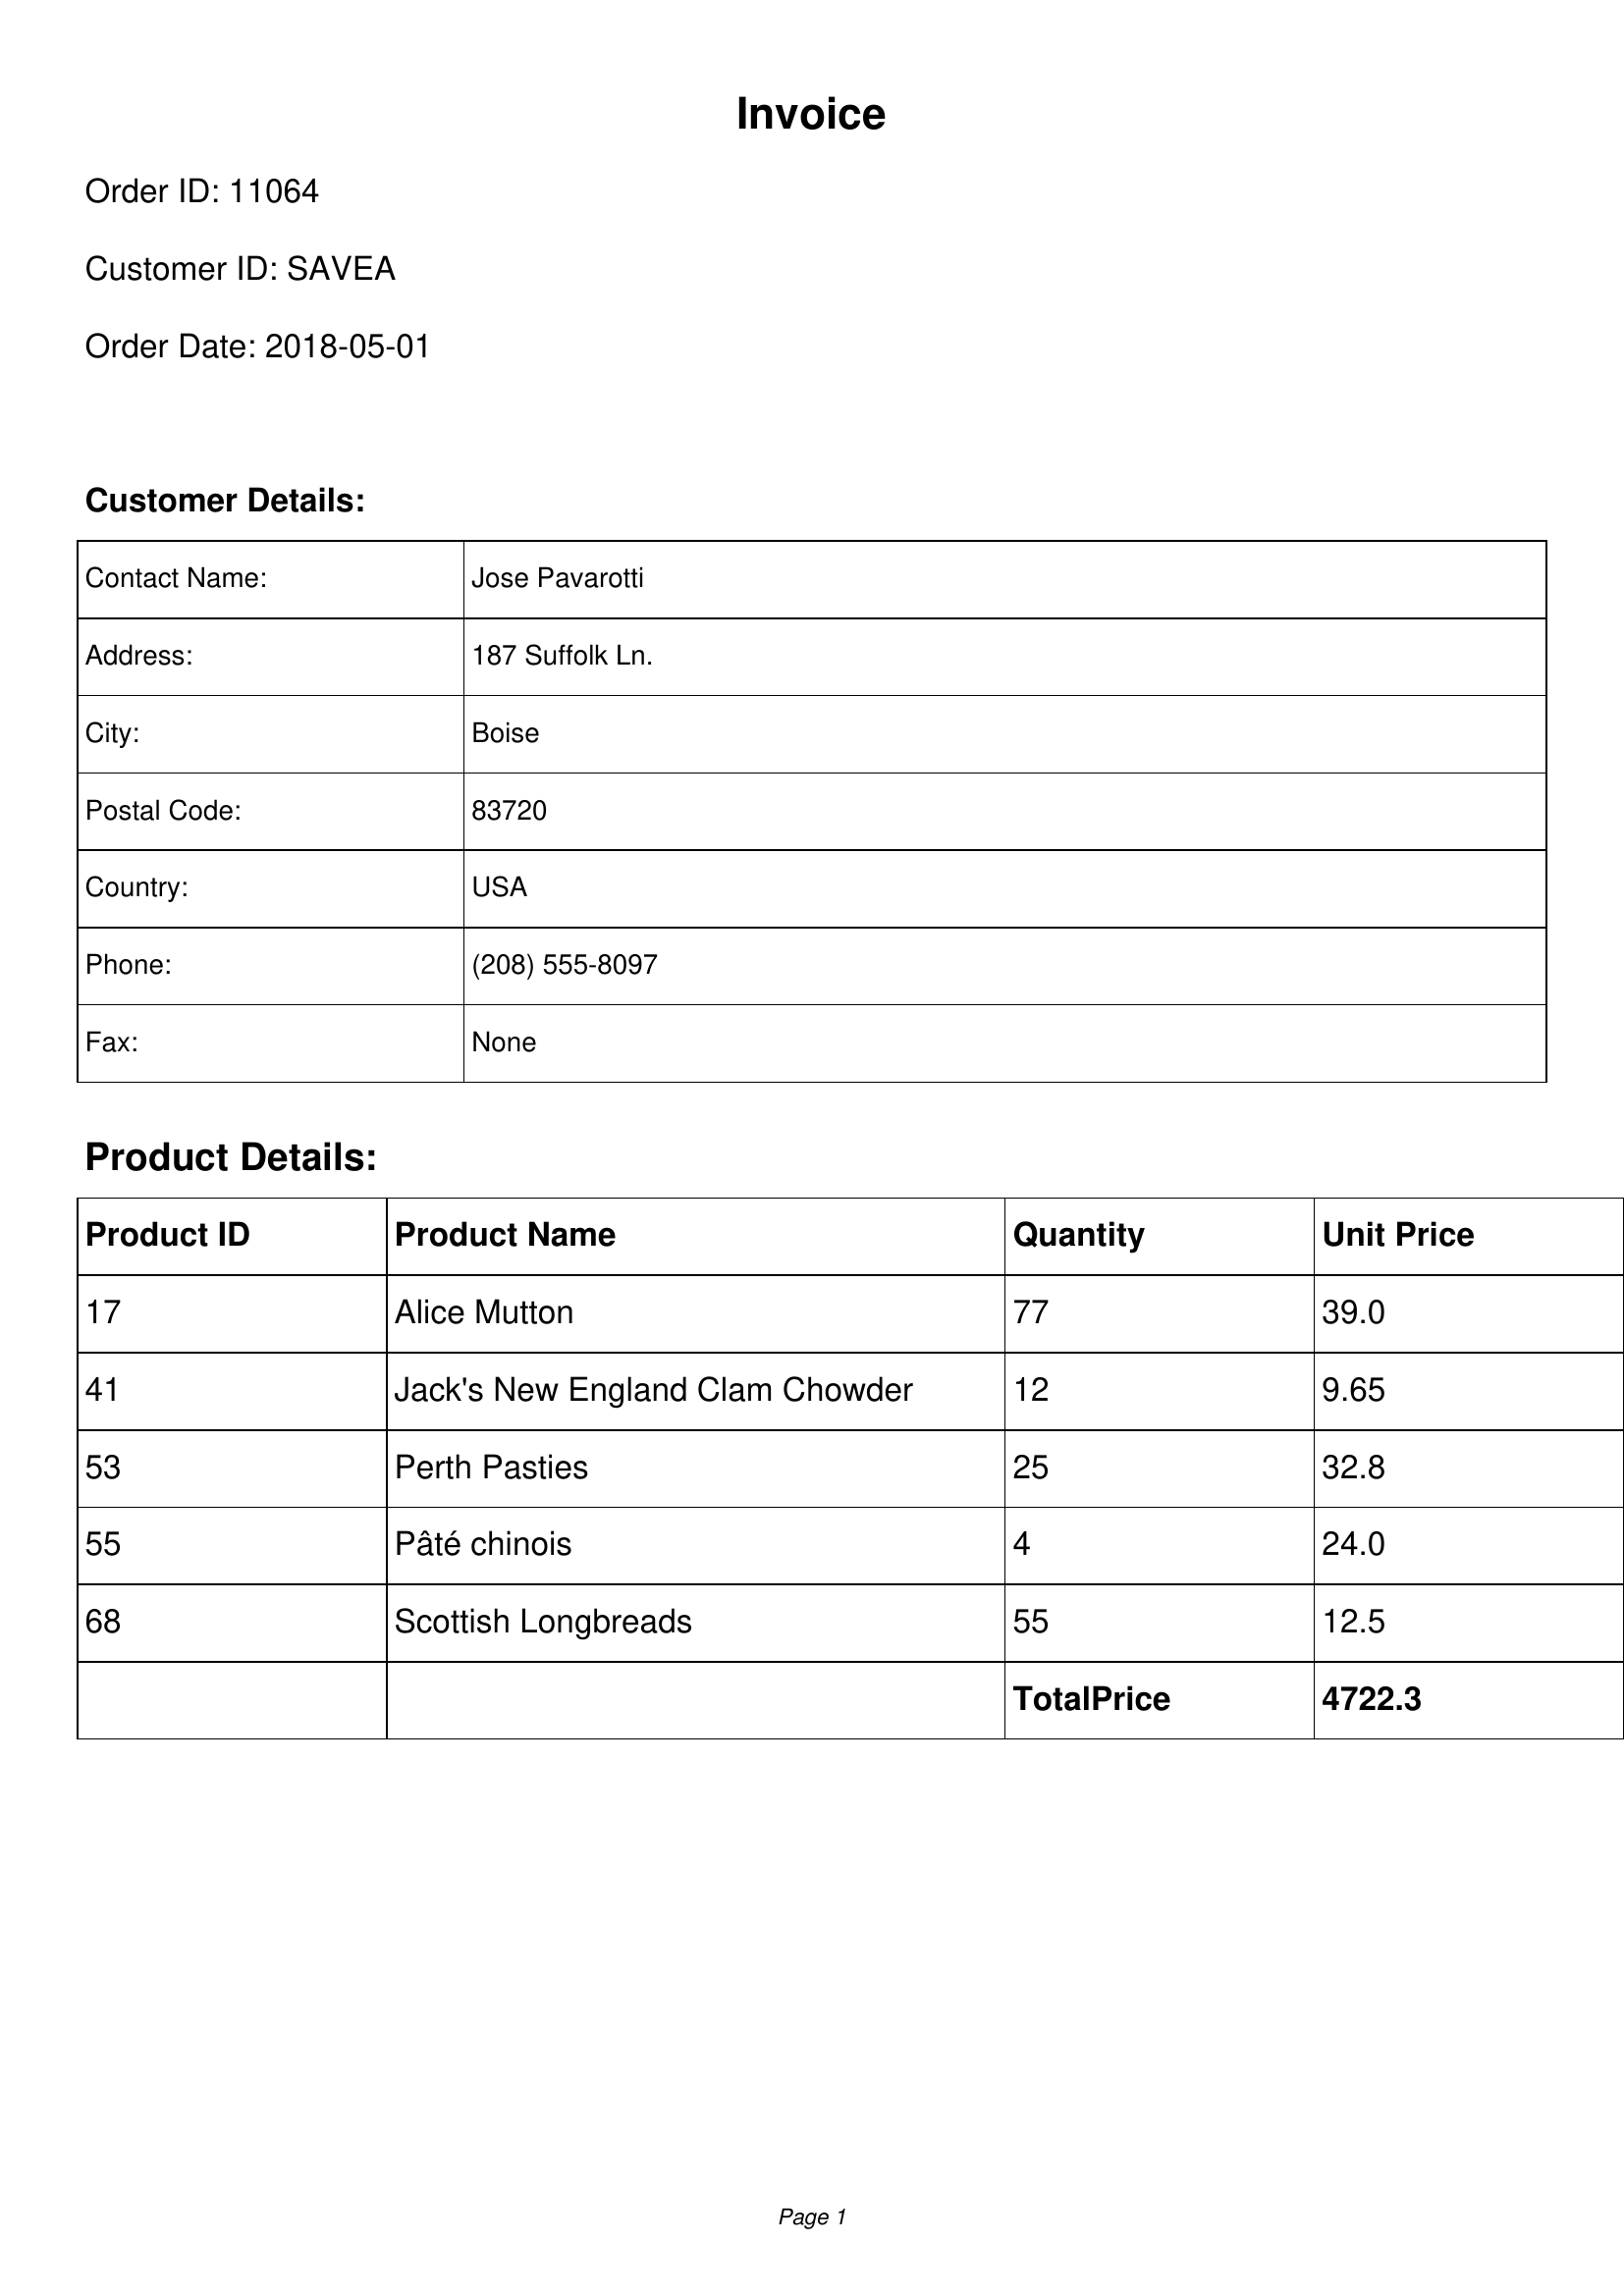

In [68]:
inv.iloc[10]['image'][0]

In [2]:
splits = {'train': 'data/train-00000-of-00001-a5c51039eab2980a.parquet', 'validation': 'data/validation-00000-of-00001-b8a5c4a6237baf25.parquet', 'test': 'data/test-00000-of-00001-56af6bd5ff7eb34d.parquet'}
df = pd.read_parquet("hf://datasets/katanaml-org/invoices-donut-data-v1/" + splits["train"])
df.head()

,image,ground_truth
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,"{""gt_parse"": {""header"": {""invoice_no"": ""403781..."
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,"{""gt_parse"": {""header"": {""invoice_no"": ""613562..."
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,"{""gt_parse"": {""header"": {""invoice_no"": ""495650..."
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,"{""gt_parse"": {""header"": {""invoice_no"": ""956116..."
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,"{""gt_parse"": {""header"": {""invoice_no"": ""260200..."


In [4]:
from PIL import Image
import io
df['image'] = df['image'].apply(lambda x: Image.open(io.BytesIO(x['bytes'])))


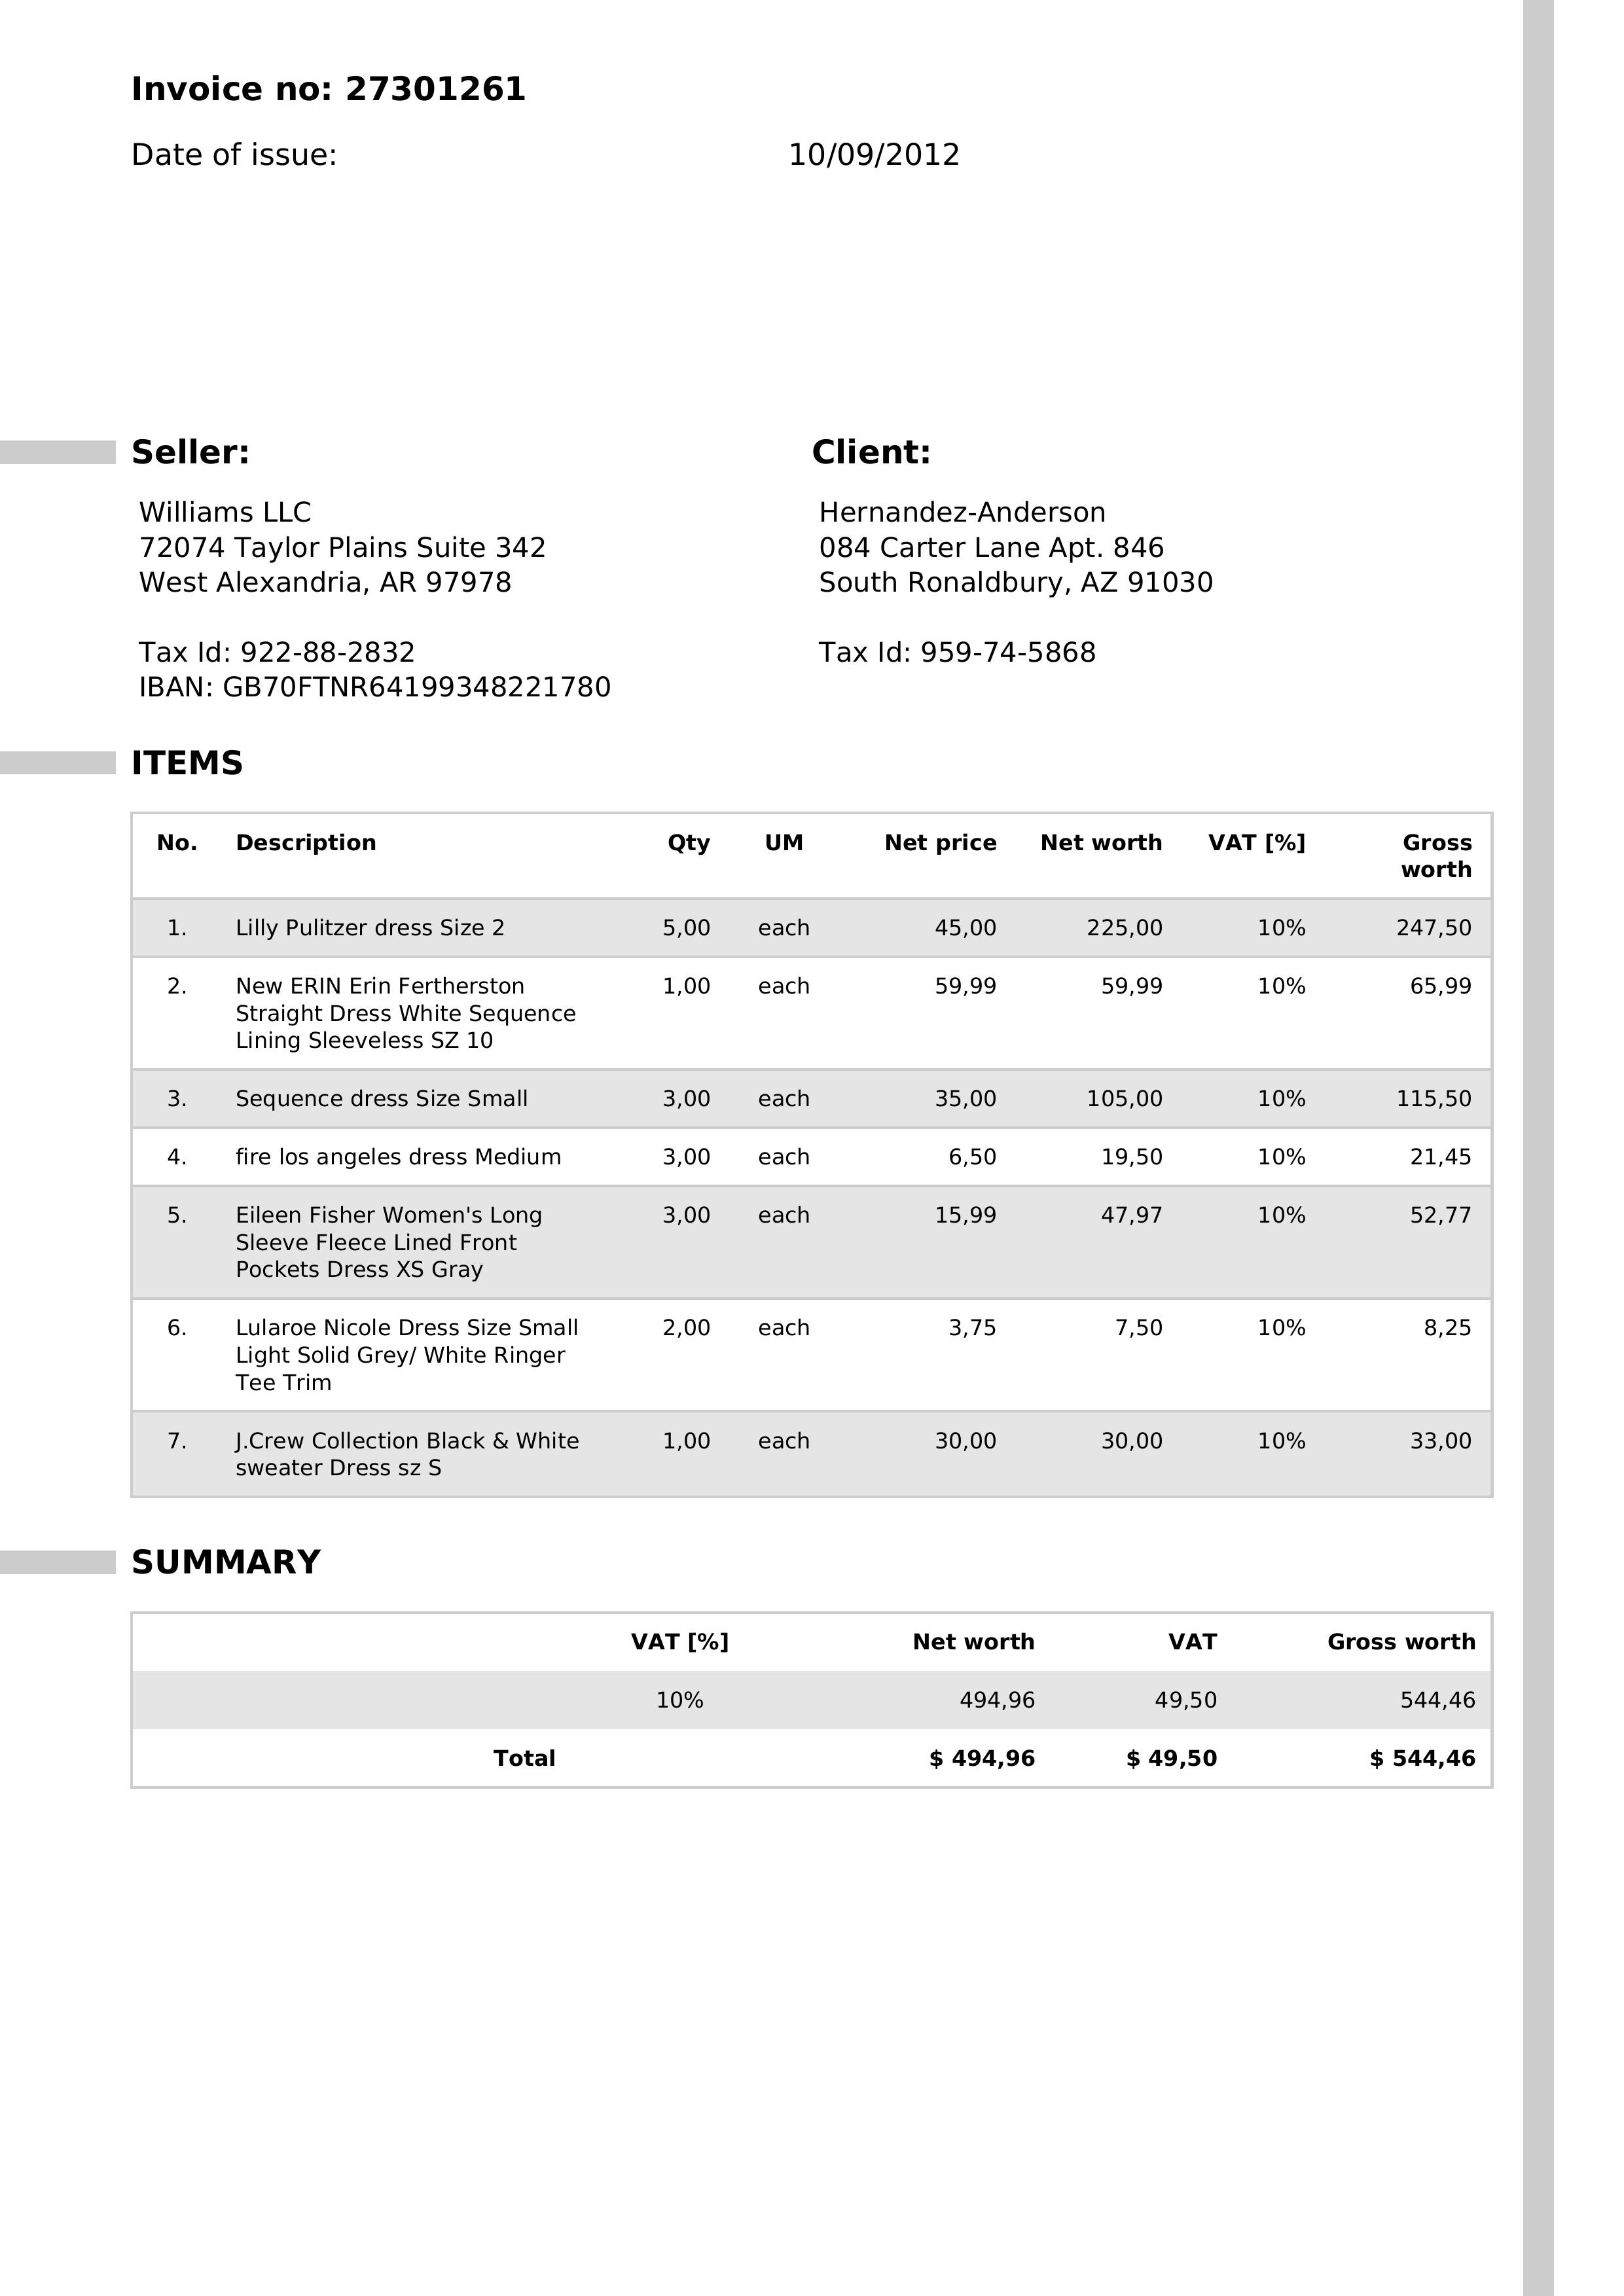

In [8]:
df.iloc[100]['image']

In [10]:
df = pd.read_csv("train.csv")

<Axes: xlabel='label'>

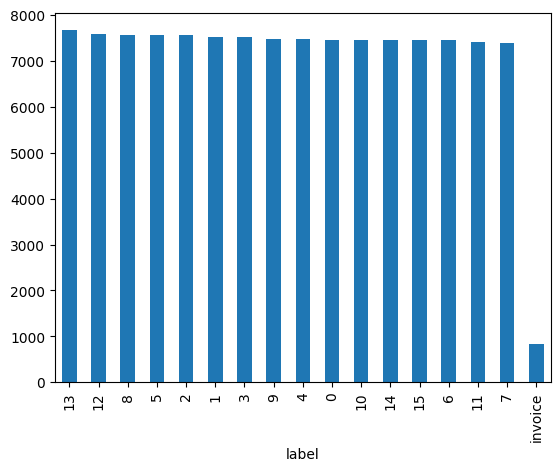

In [13]:
df['label'].value_counts().plot(kind='bar')